# EDA хз какая часть типа последняя

Добавим к итоговому датасету еще информацию с ютуба. Для ширококй публики это наиболее популярная платформа, если речь идет о видео-играх. Многие блогеры выпускают обзоры, прохождения или стримы как они играют. Для продвижения нашей будущей игры изучим влияют ли вообще просмотры и лайки на рейтинги игры.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

## Соединим датасет

In [3]:
df = pd.read_csv('./data.csv')

In [4]:
y_data = pd.read_csv('./youtube.csv')

In [5]:
final = df.merge(y_data, on='name', how='inner')
final.head()

,name,total_reviews,tags,released,rating,ratings_count,metacritic,playtime,genres,screenshots_count,reviews_score,price_usd,positive_ratio,release_year,description_word_count,count_tags,count_genres,first_genre,second_genre,third_genre,Adventure,Arcade,Casual,Indie,Massively Multiplayer,Platformer,Puzzle,RPG,Racing,Shooter,Simulation,Sports,Strategy,0,Action,Adventure,Casual,Indie,Other,RPG,Simulation,Strategy,platform_count,PlayStation,Xbox,Nintendo,Mac,PC,Linux,Android,iOS,cross_platform,yt_video_1_channel,yt_video_1_published_at,yt_video_2_channel,yt_video_2_published_at,yt_video_3_channel,yt_video_3_published_at,yt_video_4_channel,yt_video_4_published_at,yt_video_5_channel,yt_video_5_published_at,avg_duration,avg_views,avg_likes,avg_comments
0,ARC Raiders,380901.0,"Extraction Shooter,Multiplayer,PvP,PvE,Third-P...",2025-10-30,3.81,44,NaN,15,Action,6,4.0,39.99,85.870082,2025.0,22.0,20,1,Action,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,3,0,0,0,0,1,0,0,0,1,Myth,2025-05-07T03:10:51Z,videogamedunkey,2025-11-13T20:30:10Z,gameranx,2025-10-31T21:57:47Z,Fallout Plays,2025-10-29T17:25:39Z,Legacy Gaming,2025-10-29T17:56:49Z,706.0,1716002.0,36261.0,1784.0
1,Euro Truck Simulator 2,944568.0,"Driving,Transportation,Simulation,Open World,A...",2012-10-19,4.12,912,79.0,12,"Simulation, Indie",6,5.0,125.60,97.314222,2012.0,35.0,20,2,Simulation,Indie,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,3,0,0,0,0,0,1,0,0,1,Truckers universe,2023-07-30T00:15:01Z,Giocoh,2018-10-21T09:00:00Z,Linus Tech Tips,2024-07-22T17:11:55Z,The Spiffing Brit,2020-10-09T17:00:07Z,Future Games Official,2018-09-10T17:57:12Z,947.0,7490539.0,138008.0,2310.0
2,Where Winds Meet,106977.0,"Open World,Free to Play,Multiplayer,Souls-like...",2025-11-14,3.95,18,NaN,3,"Action, Adventure, RPG",4,4.0,0.00,87.071053,2025.0,55.0,20,3,Action,Adventure,RPG,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,2,0,0,0,0,1,0,0,0,1,videogamedunkey,2025-12-03T20:30:22Z,gameranx,2025-11-12T21:50:11Z,theRadBrad,2025-12-01T15:00:12Z,PlayStation,2025-11-11T19:30:09Z,KhrazeGaming,2025-11-12T18:17:41Z,2096.0,1189096.0,28701.0,2277.0
3,Wuthering Waves,43210.0,"Open World,Anime,Free to Play,Action,Adventure...",2024-05-22,4.11,27,NaN,5,"Action, Adventure, RPG",3,4.0,0.00,89.511687,2024.0,40.0,20,3,Action,Adventure,RPG,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,4,0,0,0,0,1,0,0,0,1,Wuthering Waves,2026-01-18T03:00:37Z,Wuthering Waves,2026-03-13T11:45:00Z,Wuthering Waves,2026-03-17T03:00:17Z,Wuthering Waves,2026-02-22T03:00:55Z,wtfmikxy,2024-05-30T22:56:18Z,245.0,2702273.0,31530.0,1827.0
4,Subnautica,348787.0,"Open World Survival Craft,Survival,Horror,Unde...",2018-01-23,4.24,1476,83.0,10,"Adventure, Indie",6,5.0,1.67,97.039454,2018.0,37.0,20,2,Adventure,Indie,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,7,1,0,0,0,0,0,0,0,1,Socksfor1,2020-08-16T17:09:58Z,Socksfor1,2023-07-30T16:17:53Z,Subnautica,2018-01-24T02:30:01Z,Markiplier,2015-12-23T21:42:27Z,Dive In Gaming,2024-09-12T07:32:55Z,1163.0,16019014.0,332869.0,15986.0


При соединении не потеряли никаких данных из датасета ютуба. имеем 999 игр для анализа. топчик

## Как показатели популярности влияют на рейтинг

In [36]:
#будем опираться на таргет, поэтому удалим пропуски
#в перспективе заполним с помощью мл-модельки
final_filtered=final.dropna(subset='metacritic')

In [7]:
final_filtered['metacritic'].describe()

count    445.000000
mean      80.188764
std        6.300319
min       57.000000
25%       77.000000
50%       80.000000
75%       84.000000
max       96.000000
Name: metacritic, dtype: float64



Видим что 25 перцентиль довольно большой, то есть большинство игр имеют достаточно высокий рейтинг и для наглядности отфильруем датасет.

In [8]:
final_filtered = final[final['metacritic'] > 77]

Отлично! теперь проаналируем зависимости между ключевыми показателями популярности роликов и рейтингом

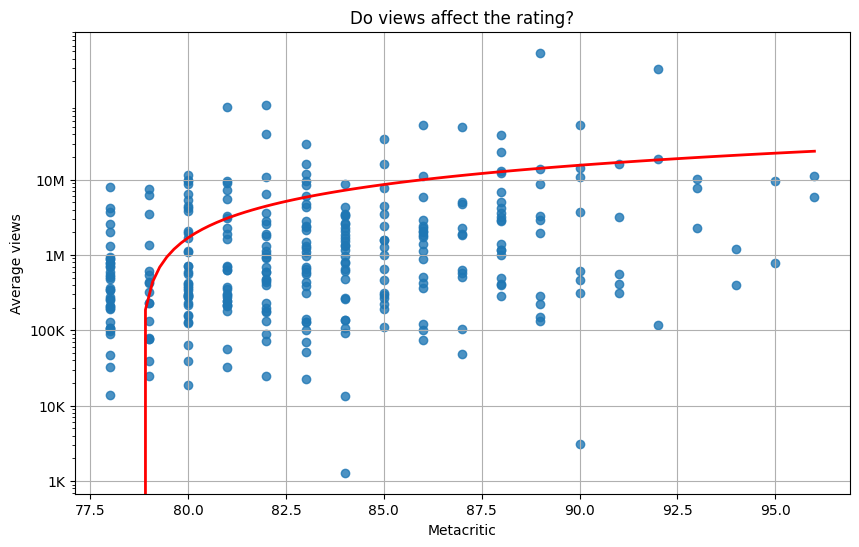

In [9]:
plt.figure(figsize=(10, 6))
sns.regplot(data=final_filtered, x='metacritic', y='avg_views', line_kws={'color':'red', 'lw':2}, ci=None)

plt.title('Do views affect the rating?')
plt.xlabel('Metacritic')
plt.ylabel('Average views')
plt.yscale('log') #логарифмируем так как есть сильные выбросы и просмотры в целом большие
plt.yticks([1e3, 1e4, 1e5, 1e6, 1e7], 
           ['1K', '10K', '100K', '1M', '10M'])
plt.grid()
plt.show()

In [14]:
#для боксплотов сделаем разбивку на бины для красоты
bins = [77, 80, 85, 90, 100]
labels = ['77-80', '80-85', '85-90', '90-100']

final_filtered['rating_bin'] = pd.cut(final_filtered['metacritic'], bins=bins, labels=labels, include_lowest=True)

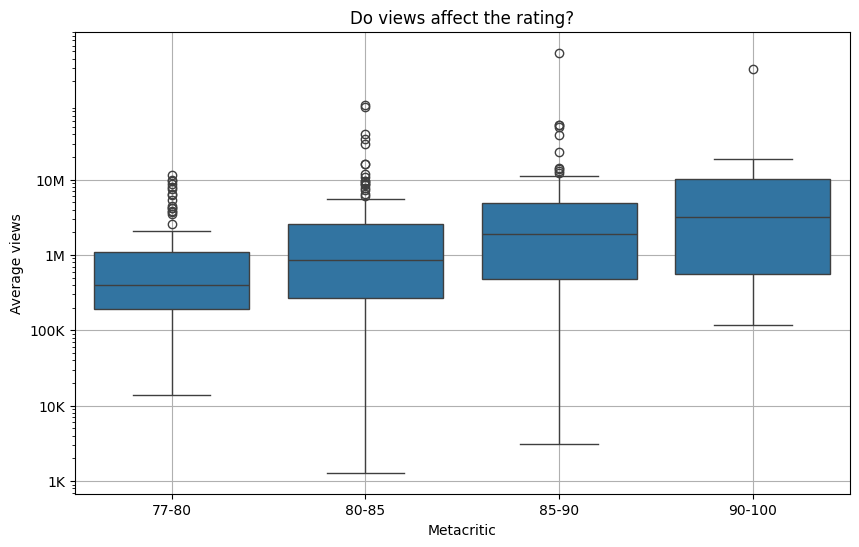

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=final_filtered, x='rating_bin', y='avg_views')

plt.title('Do views affect the rating?')
plt.xlabel('Metacritic')
plt.ylabel('Average views')
plt.yscale('log') #логарифмируем так как есть сильные выбросы и просмотры в целом большие
plt.yticks([1e3, 1e4, 1e5, 1e6, 1e7], 
           ['1K', '10K', '100K', '1M', '10M'])
plt.grid()
plt.show()

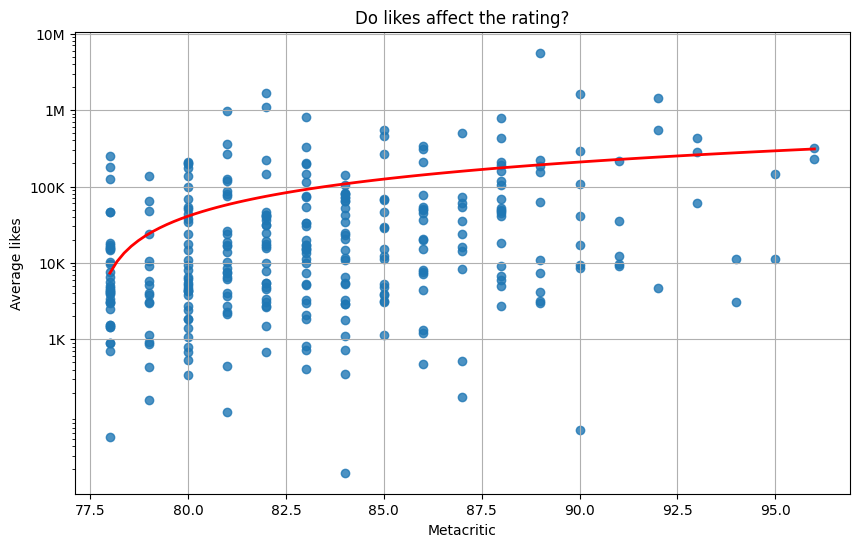

In [16]:
plt.figure(figsize=(10, 6))
sns.regplot(data=final_filtered, x='metacritic', y='avg_likes', line_kws={'color':'red', 'lw':2}, ci=None)

plt.title('Do likes affect the rating?')
plt.xlabel('Metacritic')
plt.ylabel('Average likes')
plt.yscale('log')
plt.yticks([1e3, 1e4, 1e5, 1e6, 1e7], 
           ['1K', '10K', '100K', '1M', '10M'])
plt.grid()
plt.show()

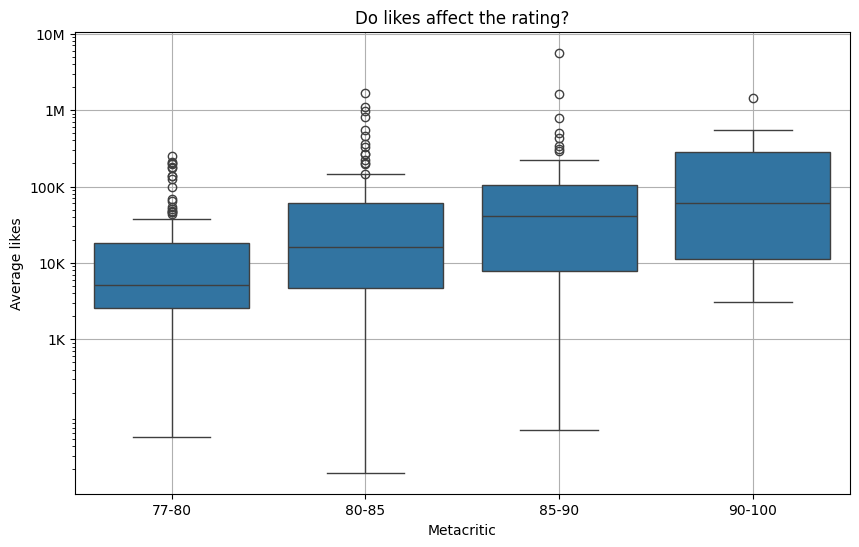

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=final_filtered, x='rating_bin', y='avg_likes')

plt.title('Do likes affect the rating?')
plt.xlabel('Metacritic')
plt.ylabel('Average likes')
plt.yscale('log')
plt.yticks([1e3, 1e4, 1e5, 1e6, 1e7], 
           ['1K', '10K', '100K', '1M', '10M'])
plt.grid()
plt.show()

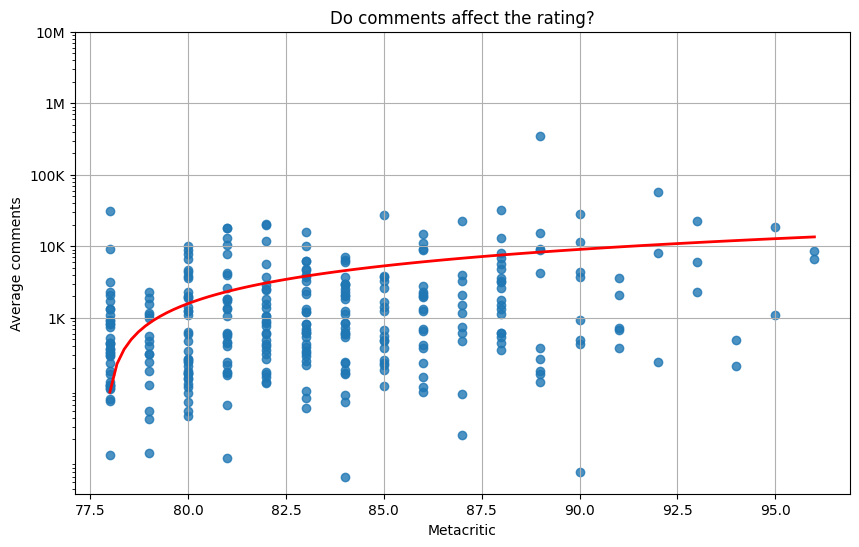

In [18]:
plt.figure(figsize=(10, 6))
sns.regplot(data=final_filtered, x='metacritic', y='avg_comments', line_kws={'color':'red', 'lw':2}, ci=None)

plt.title('Do comments affect the rating?')
plt.xlabel('Metacritic')
plt.ylabel('Average comments')
plt.yscale('log')
plt.yticks([1e3, 1e4, 1e5, 1e6, 1e7], 
           ['1K', '10K', '100K', '1M', '10M'])
plt.grid()
plt.show()

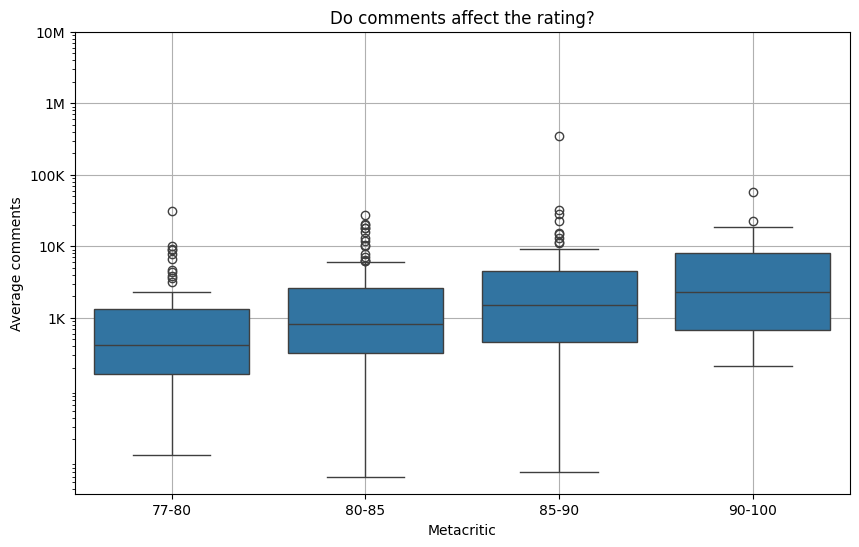

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=final_filtered, x='rating_bin', y='avg_comments')

plt.title('Do comments affect the rating?')
plt.xlabel('Metacritic')
plt.ylabel('Average comments')
plt.yscale('log')
plt.yticks([1e3, 1e4, 1e5, 1e6, 1e7], 
           ['1K', '10K', '100K', '1M', '10M'])
plt.grid()
plt.show()

Для всех показателей видим overall позитивную динамику(не забываем, что показатели логарифмированы). Связь нельзя назвать сильной, однако влияние явно имеется.

## Engagement

Создадим новый показатель "вовлечение" - сумма лайков и комментариев, деленная на просмотры

In [20]:
final_filtered['engagement'] = (final_filtered['avg_likes'] + final_filtered['avg_comments']) / final_filtered['avg_views']
final['engagement'] = (final['avg_likes'] + final['avg_comments']) / final['avg_views']

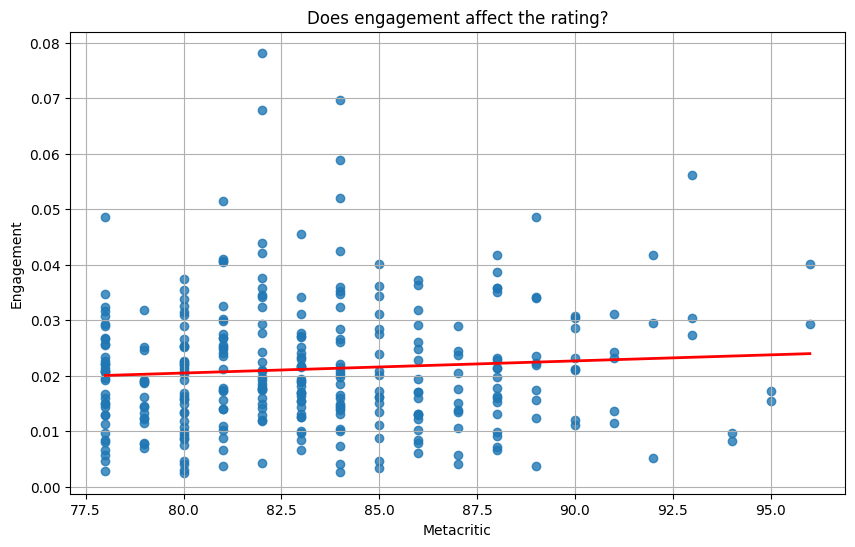

In [21]:
plt.figure(figsize=(10, 6))
sns.regplot(data=final_filtered, x='metacritic', y='engagement', line_kws={'color':'red', 'lw':2}, ci=None)

plt.title('Does engagement affect the rating?')
plt.xlabel('Metacritic')
plt.ylabel('Engagement')
plt.grid()
plt.show()

Очень слегка имеем положительную динамику.

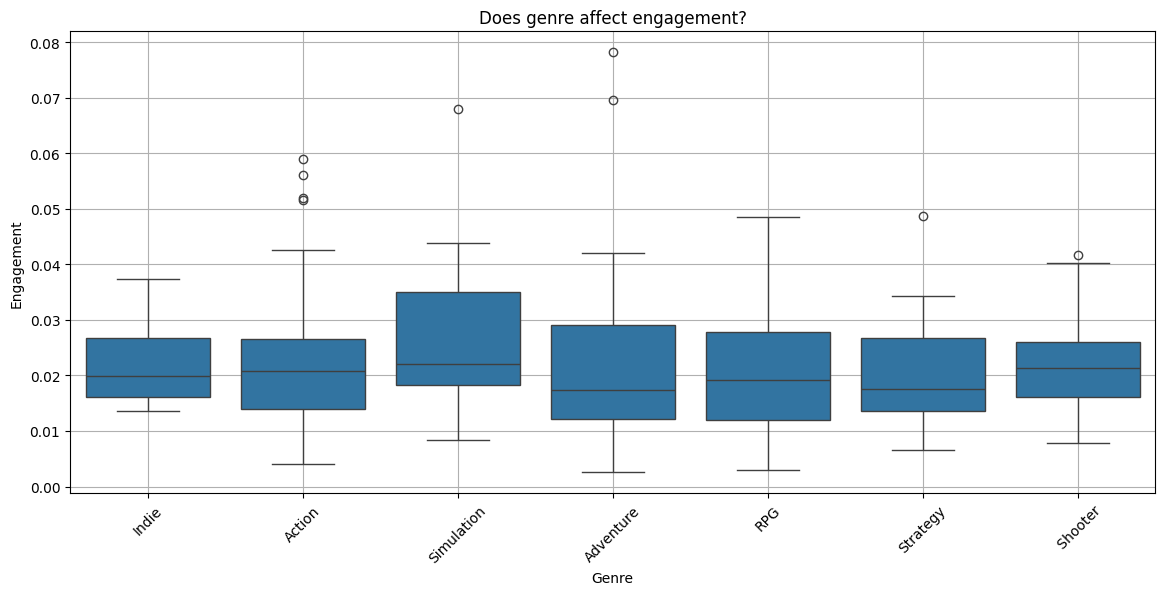

In [22]:
genre_cols = ['Indie', 'Action', 'Simulation', 'Adventure', 'RPG', 'Strategy', 'Shooter']

final_long = final_filtered.melt(id_vars=['engagement'], value_vars=genre_cols, var_name='genre', value_name='is_genre')
final_long = final_long[final_long['is_genre'] == 1]

plt.figure(figsize=(14, 6))
sns.boxplot(data=final_long, x='genre', y='engagement')

plt.xticks(rotation=45)
plt.title('Does genre affect engagement?')
plt.xlabel('Genre')
plt.ylabel('Engagement')
plt.grid()
plt.show()

Можем сказать, что жанр особо сильно на вовлечение не влияет. Видим, что Strategy не особо интересен (видимо зрители не хотят случайно увидеть спойлер), в то же время Simulation слегка вырывается вперед.

In [23]:
#для боксплотов сделаем разбивку на бины для красоты
bins = [-1, 0, 6, 10, 13, 90, float('inf')]
labels = ['0', '0-6', '6-10', '10-13', '13-90', '90+']

final['rating_bin_price'] = pd.cut(final['price_usd'], bins=bins, labels=labels, include_lowest=True)

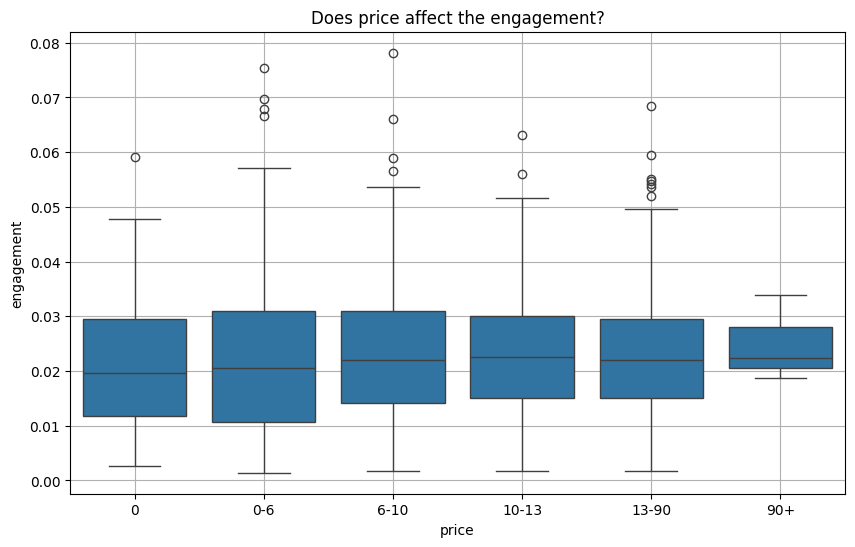

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=final, x='rating_bin_price', y='engagement')

plt.title('Does price affect the engagement?')
plt.xlabel('price')
plt.ylabel('engagement')
plt.grid()
plt.show()

Опять сильной разницы нет, модем только сказать, что медианно бесплатные игры не особо смотрят, в них все-таки видисо играют))

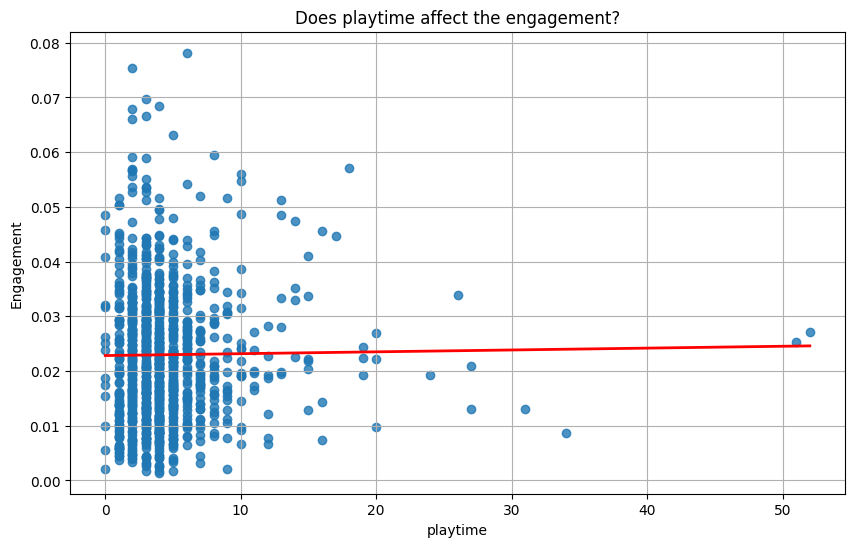

In [32]:
plt.figure(figsize=(10, 6))
sns.regplot(data=final, x='playtime', y='engagement', line_kws={'color':'red', 'lw':2}, ci=None)

plt.title('Does playtime affect the engagement?')
plt.xlabel('playtime')
plt.ylabel('Engagement')
plt.grid()
plt.show()

вообще без разницы ему...

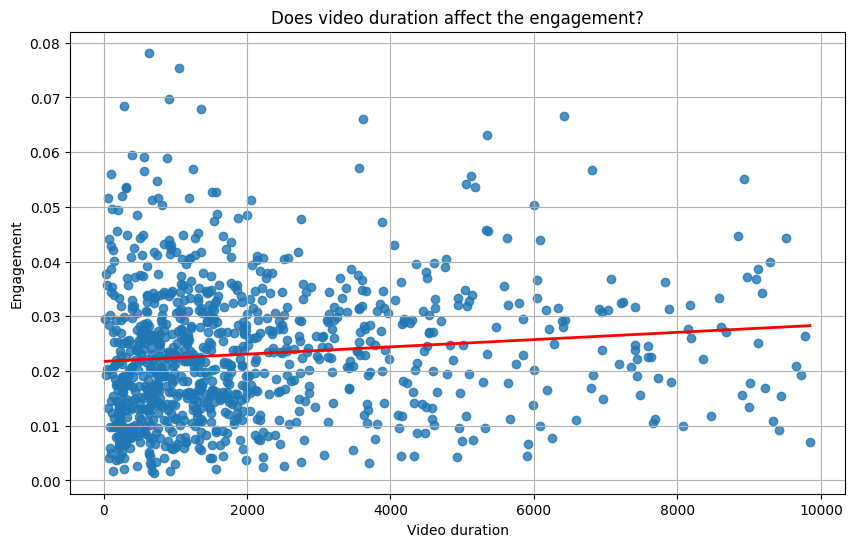

In [35]:
plt.figure(figsize=(10, 6))
sns.regplot(data=final[final['avg_duration'] < 10000], x='avg_duration', y='engagement', line_kws={'color':'red', 'lw':2}, ci=None)

plt.title('Does video duration affect the engagement?')
plt.xlabel('Video duration')
plt.ylabel('Engagement')
plt.grid()
plt.show()

In [ ]:
ну тут хоть немного положительно, хотя более часто конечно короткие видео снимают, так что нельзя сказать, что эта динамика релевантна

**Итог по вовлечению** нельзя сказать, что какие-то признаки сильно влияют на вовлечение. Видимо, все-таки важнее именно "интересность" самой игры :)

## В общем и целом

Можем сказать, что вовлечение и показатели популярности видео-ролика влияют на рейтинг игры. Соответственно продвижение через ютуб-блогеров можем рассматривать как хороший канал. Однако выяснить какие именно показатели самой игры влияюи на вовлечение не вышло. Имеем гипотезу, что для любви геймеров в первую важно наполнение и суть игры, а не поверхностные метрики :) 